# Free Game Prediction Model - Epic Games Store
## Predicting when games will appear free on Epic Games Store
### Model: XGBoost Gradient Boosting Classifier

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load and Clean Data

In [3]:
# Load Epic Games data
epic_df = pd.read_csv('Epic.csv')

# Remove empty rows
epic_df_clean = epic_df[epic_df['game_name'].notna()].copy()

print(f"Total games loaded: {len(epic_df_clean)}")
print(f"\nColumns: {list(epic_df_clean.columns)}")
print(f"\nMissing values:")
print(epic_df_clean.isnull().sum())

Total games loaded: 586

Columns: ['game_name', 'release_date', 'Added to Service', 'Removed from Service', 'metacritic_score', 'publisher', 'developer']

Missing values:
game_name                 0
release_date             11
Added to Service          0
Removed from Service      0
metacritic_score        222
publisher                15
developer                 4
dtype: int64


## Step 2: Date Processing and Feature Engineering

In [4]:
# Parse dates
def parse_dates(date_str):
    """Parse dates handling multiple formats"""
    if pd.isna(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str, format='%m/%d/%Y', errors='coerce')
    except:
        return pd.NaT

epic_df_clean['release_date'] = epic_df_clean['release_date'].apply(parse_dates)
epic_df_clean['added_to_service'] = epic_df_clean['Added to Service'].apply(parse_dates)

# Calculate days from release to Epic free offering
epic_df_clean['days_to_epic'] = (epic_df_clean['added_to_service'] - epic_df_clean['release_date']).dt.days

# Only keep games with valid timing data
epic_df_with_timing = epic_df_clean[epic_df_clean['days_to_epic'].notna()].copy()

print(f"Games with valid timing data: {len(epic_df_with_timing)}")
print(f"\nTiming statistics (days from release to Epic free):")
print(f"  Minimum: {epic_df_with_timing['days_to_epic'].min():.0f} days")
print(f"  Maximum: {epic_df_with_timing['days_to_epic'].max():.0f} days")
print(f"  Mean: {epic_df_with_timing['days_to_epic'].mean():.0f} days")
print(f"  Median: {epic_df_with_timing['days_to_epic'].median():.0f} days")

Games with valid timing data: 575

Timing statistics (days from release to Epic free):
  Minimum: -519 days
  Maximum: 9572 days
  Mean: 1566 days
  Median: 1240 days


## Step 3: Process Publishers and Developers (Handle Multiple Entries)

In [5]:
def split_and_clean(value):
    """Split comma-separated values and return as list"""
    if pd.isna(value):
        return []
    items = [item.strip() for item in str(value).split(',')]
    return [item for item in items if item]

# Create lists of publishers and developers
epic_df_with_timing['publishers_list'] = epic_df_with_timing['publisher'].apply(split_and_clean)
epic_df_with_timing['developers_list'] = epic_df_with_timing['developer'].apply(split_and_clean)

# Count multiple publishers/developers
epic_df_with_timing['num_publishers'] = epic_df_with_timing['publishers_list'].apply(len)
epic_df_with_timing['num_developers'] = epic_df_with_timing['developers_list'].apply(len)

# Get primary publisher (first in list)
epic_df_with_timing['primary_publisher'] = epic_df_with_timing['publishers_list'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

print(f"\nTop 10 Publishers (by game count):")
print(epic_df_with_timing['primary_publisher'].value_counts().head(10))

print(f"\nGames with multiple publishers: {(epic_df_with_timing['num_publishers'] > 1).sum()}")
print(f"Games with multiple developers: {(epic_df_with_timing['num_developers'] > 1).sum()}")


Top 10 Publishers (by game count):
primary_publisher
Team17 Digital            20
Bethesda Softworks        19
Unknown                   15
Devolver Digital          13
Daedalic Entertainment    13
Deep Silver               12
Square Enix               10
Microsoft Studios         10
505 Games                 10
Focus Home Interactive     9
Name: count, dtype: int64

Games with multiple publishers: 196
Games with multiple developers: 250


## Step 4: Calculate Publisher Statistics (Historical Behavior)

In [6]:
# Calculate average days_to_epic per publisher
publisher_stats = epic_df_with_timing.groupby('primary_publisher').agg({
    'days_to_epic': ['mean', 'median', 'std', 'count'],
    'metacritic_score': ['mean', 'count']
}).round(2)

publisher_stats.columns = ['avg_days_to_epic', 'median_days_to_epic', 'std_days_to_epic', 
                           'games_count', 'avg_metacritic', 'metacritic_count']
publisher_stats = publisher_stats.reset_index()

# Calculate percentage of games with Metacritic scores
publisher_stats['metacritic_coverage'] = (
    publisher_stats['metacritic_count'] / publisher_stats['games_count'] * 100
).round(2)

# Only keep publishers with at least 3 games for reliable statistics
publisher_stats_filtered = publisher_stats[publisher_stats['games_count'] >= 3].copy()

print(f"\nPublisher Statistics (publishers with 3+ games):")
print(publisher_stats_filtered.sort_values('avg_days_to_epic').head(10))

# Merge publisher statistics back to main dataframe
epic_df_with_timing = epic_df_with_timing.merge(
    publisher_stats[['primary_publisher', 'avg_days_to_epic', 'median_days_to_epic', 
                     'games_count', 'avg_metacritic']],
    on='primary_publisher',
    how='left',
    suffixes=('', '_publisher')
)


Publisher Statistics (publishers with 3+ games):
       primary_publisher  avg_days_to_epic  median_days_to_epic  \
239            Wargaming            108.67                167.0   
134          Modus Games            254.33                219.0   
183       Skybound Games            510.20                537.0   
176    Saber Interactive            569.86                499.0   
20   Armor Games Studios            703.67                731.0   
10         Akupara Games            714.00                703.0   
44         Curve Digital            770.80                735.0   
243    Wired Productions            794.00                707.0   
50      Devolver Digital            812.15                772.0   
232       Uppercut Games            818.33                637.0   

     std_days_to_epic  games_count  avg_metacritic  metacritic_count  \
239            600.63            3             NaN                 0   
134            106.49            3           73.50                 2

## Step 5: Create Target Variable (Time Categories)

In [7]:
def categorize_timing(days):
    """
    Categorize games into timing buckets:
    - Within 6 months: 0-180 days
    - Next 12 months: 181-545 days (6-18 months)
    - More than 12 months: 546-1825 days (18 months - 5 years)
    - As Good as Never: 1826+ days (5+ years)
    """
    if pd.isna(days):
        return 'Unknown'
    elif days <= 180:
        return 'Within 6 months'
    elif days <= 545:
        return 'Next 12 months'
    elif days <= 1825:
        return 'More than 12 months'
    else:
        return 'As Good as Never'

epic_df_with_timing['timing_category'] = epic_df_with_timing['days_to_epic'].apply(categorize_timing)

print("\nTarget Variable Distribution:")
print(epic_df_with_timing['timing_category'].value_counts())
print(f"\nPercentages:")
print(epic_df_with_timing['timing_category'].value_counts(normalize=True).mul(100).round(2))


Target Variable Distribution:
timing_category
More than 12 months    277
As Good as Never       191
Next 12 months          79
Within 6 months         28
Name: count, dtype: int64

Percentages:
timing_category
More than 12 months    48.17
As Good as Never       33.22
Next 12 months         13.74
Within 6 months         4.87
Name: proportion, dtype: float64


## Step 6: Feature Engineering for Model

In [8]:
# Fill missing Metacritic scores with publisher average
epic_df_with_timing['metacritic_filled'] = epic_df_with_timing['metacritic_score'].fillna(
    epic_df_with_timing['avg_metacritic']
)

# If still missing, use overall average
overall_avg_meta = epic_df_with_timing['metacritic_score'].mean()
epic_df_with_timing['metacritic_filled'] = epic_df_with_timing['metacritic_filled'].fillna(overall_avg_meta)

# Create features
epic_df_with_timing['has_metacritic'] = epic_df_with_timing['metacritic_score'].notna().astype(int)
epic_df_with_timing['release_year'] = epic_df_with_timing['release_date'].dt.year
epic_df_with_timing['release_month'] = epic_df_with_timing['release_date'].dt.month

# Publisher reputation score (based on average timing)
epic_df_with_timing['publisher_speed_score'] = (
    1 / (epic_df_with_timing['avg_days_to_epic'] / 365)
).fillna(0.5)  # Default for unknown publishers

print("\nFeatures created:")
print("  - metacritic_filled: Metacritic score (filled with publisher avg)")
print("  - has_metacritic: Binary indicator if original score exists")
print("  - release_year: Year of game release")
print("  - release_month: Month of game release")
print("  - num_publishers: Count of publishers")
print("  - num_developers: Count of developers")
print("  - games_count: Publisher's total game count")
print("  - avg_days_to_epic: Publisher's historical average")
print("  - publisher_speed_score: Inverse timing metric")
print("  - primary_publisher: Main publisher (categorical)")


Features created:
  - metacritic_filled: Metacritic score (filled with publisher avg)
  - has_metacritic: Binary indicator if original score exists
  - release_year: Year of game release
  - release_month: Month of game release
  - num_publishers: Count of publishers
  - num_developers: Count of developers
  - games_count: Publisher's total game count
  - avg_days_to_epic: Publisher's historical average
  - publisher_speed_score: Inverse timing metric
  - primary_publisher: Main publisher (categorical)


## Step 7: Prepare Data for Modeling

In [9]:
# Select features for modeling
feature_columns = [
    'metacritic_filled',
    'has_metacritic',
    'release_year',
    'release_month',
    'num_publishers',
    'num_developers',
    'games_count',
    'avg_days_to_epic',
    'publisher_speed_score',
    'primary_publisher'
]

# Prepare modeling dataset
model_df = epic_df_with_timing[feature_columns + ['timing_category']].copy()
model_df = model_df.dropna(subset=['timing_category'])

# Encode categorical variables
le_publisher = LabelEncoder()
model_df['publisher_encoded'] = le_publisher.fit_transform(model_df['primary_publisher'])

le_target = LabelEncoder()
model_df['target_encoded'] = le_target.fit_transform(model_df['timing_category'])

# Define feature set
X_features = [
    'metacritic_filled', 'has_metacritic', 'release_year', 'release_month',
    'num_publishers', 'num_developers', 'games_count', 'avg_days_to_epic',
    'publisher_speed_score', 'publisher_encoded'
]

X = model_df[X_features]
y = model_df['target_encoded']

print(f"\nDataset ready for modeling:")
print(f"  Total samples: {len(X)}")
print(f"  Features: {len(X_features)}")
print(f"  Target classes: {len(le_target.classes_)}")
print(f"  Class labels: {le_target.classes_}")


Dataset ready for modeling:
  Total samples: 575
  Features: 10
  Target classes: 4
  Class labels: ['As Good as Never' 'More than 12 months' 'Next 12 months'
 'Within 6 months']


## Step 8: Train XGBoost Model

In [ ]:
# Step 8: Train XGBoost Model (FIXED VERSION)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# FIX: Handle infinite values in publisher_speed_score
# Replace inf with NaN, then fill with maximum valid value
model_df['publisher_speed_score'] = model_df['publisher_speed_score'].replace([np.inf, -np.inf], np.nan)
max_valid_speed = model_df['publisher_speed_score'].max()
model_df['publisher_speed_score'] = model_df['publisher_speed_score'].fillna(max_valid_speed)

print(f"Fixed infinite values in publisher_speed_score")
print(f"Remaining NaN: {model_df['publisher_speed_score'].isna().sum()}")
print(f"Remaining Inf: {np.isinf(model_df['publisher_speed_score']).sum()}")

# Encode categorical variables
le_publisher = LabelEncoder()
model_df['publisher_encoded'] = le_publisher.fit_transform(model_df['primary_publisher'])

le_target = LabelEncoder()
model_df['target_encoded'] = le_target.fit_transform(model_df['timing_category'])

# Define feature set
X_features = [
    'metacritic_filled', 'has_metacritic', 'release_year', 'release_month',
    'num_publishers', 'num_developers', 'games_count', 'avg_days_to_epic',
    'publisher_speed_score', 'publisher_encoded'
]

X = model_df[X_features]
y = model_df['target_encoded']

# Final validation - ensure no NaN or Inf in features
assert not X.isnull().any().any(), "Features contain NaN values!"
assert not np.isinf(X.values).any(), "Features contain Inf values!"

print(f"\nDataset validated and ready:")
print(f"  Total samples: {len(X)}")
print(f"  Features: {len(X_features)}")
print(f"  Target classes: {le_target.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0  # Suppress warnings
)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)

# Evaluate
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

print(f"\nModel Performance:")
print(f"  Training Accuracy: {train_score:.4f}")
print(f"  Testing Accuracy: {test_score:.4f}")

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Fixed infinite values in publisher_speed_score
Remaining NaN: 0
Remaining Inf: 0

Dataset validated and ready:
  Total samples: 575
  Features: 10
  Target classes: ['As Good as Never' 'More than 12 months' 'Next 12 months'
 'Within 6 months']

Training XGBoost model...

Model Performance:
  Training Accuracy: 0.9652
  Testing Accuracy: 0.7043

Performing 5-fold cross-validation...
5-Fold Cross-Validation Scores: [0.57391304 0.80869565 0.68695652 0.76521739 0.68695652]
Mean CV Accuracy: 0.7043 (+/- 0.1605)


## Step 9: Feature Importance Analysis


Feature Importance Rankings:
                 feature  importance
2           release_year    0.268059
7       avg_days_to_epic    0.155683
8  publisher_speed_score    0.142998
6            games_count    0.075913
4         num_publishers    0.067885
0      metacritic_filled    0.063107
5         num_developers    0.061699
3          release_month    0.057607
1         has_metacritic    0.054948
9      publisher_encoded    0.052101


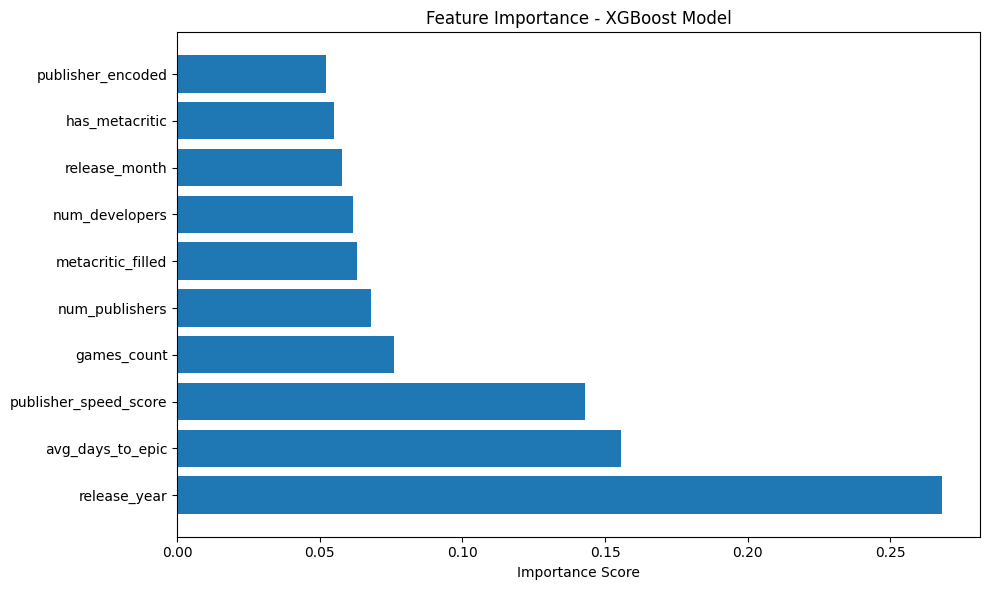

In [11]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Rankings:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - XGBoost Model')
plt.tight_layout()
plt.show()

## Step 10: Prediction Function with Pre-baked Sentence Generation

In [12]:
# Step 10: Prediction Function with Pre-baked Sentence Generation (FIXED)

def predict_game_timing(game_name, publisher, metacritic_score=None, release_year=2024, release_month=1):
    """
    Predict when a game will appear free on Epic Games Store
    
    Returns: Pre-baked sentence with prediction
    """
    
    # Get publisher statistics
    if publisher in publisher_stats['primary_publisher'].values:
        pub_stats = publisher_stats[publisher_stats['primary_publisher'] == publisher].iloc[0]
        avg_days = pub_stats['avg_days_to_epic']
        games_count = pub_stats['games_count']
        avg_meta = pub_stats['avg_metacritic']
        publisher_encoded = le_publisher.transform([publisher])[0]
    else:
        # FIXED: Return complete dictionary structure for unknown publishers
        avg_days = epic_df_with_timing['avg_days_to_epic'].mean()
        games_count = 0
        avg_meta = overall_avg_meta
        
        return {
            'game_name': game_name,  # ADDED
            'publisher': publisher,   # ADDED
            'prediction': 'Unknown',
            'confidence': 0.0,        # ADDED
            'sentence': f"Based on the publisher '{publisher}', which has no historical data in our Epic Games dataset, we cannot make a reliable prediction. The publisher is not yet established in Epic's free games program.",
            'publisher_avg_days': avg_days,       # ADDED
            'publisher_avg_metacritic': avg_meta, # ADDED
            'publisher_game_count': games_count   # ADDED
        }
    
    # Handle missing Metacritic
    if metacritic_score is None:
        metacritic_filled = avg_meta
        has_metacritic = 0
    else:
        metacritic_filled = metacritic_score
        has_metacritic = 1
    
    # Create feature vector
    publisher_speed = 1 / (avg_days / 365) if avg_days > 0 else 0.5
    
    features = pd.DataFrame([{
        'metacritic_filled': metacritic_filled,
        'has_metacritic': has_metacritic,
        'release_year': release_year,
        'release_month': release_month,
        'num_publishers': 1,
        'num_developers': 1,
        'games_count': games_count,
        'avg_days_to_epic': avg_days,
        'publisher_speed_score': publisher_speed,
        'publisher_encoded': publisher_encoded
    }])
    
    # Make prediction
    pred_encoded = xgb_model.predict(features)[0]
    prediction = le_target.inverse_transform([pred_encoded])[0]
    probabilities = xgb_model.predict_proba(features)[0]
    confidence = probabilities[pred_encoded] * 100
    
    # Generate pre-baked sentence
    meta_text = f"with a Metacritic score of {metacritic_score}" if metacritic_score else "without an available Metacritic score"
    
    avg_years = int(avg_days / 365)
    avg_months = int((avg_days % 365) / 30)
    
    sentence = (
        f"Based on the publisher '{publisher}', which has released {int(games_count)} "
        f"game{'s' if games_count > 1 else ''} on Epic Games Store with an average wait time of "
        f"{avg_years} year{'s' if avg_years != 1 else ''} and {avg_months} month{'s' if avg_months != 1 else ''} "
        f"(averaging a Metacritic score of {avg_meta:.1f}), "
        f"and considering '{game_name}' {meta_text}, "
        f"the game is estimated to appear free on Epic Games Store: **{prediction}** "
        f"(confidence: {confidence:.1f}%)."
    )
    
    return {
        'game_name': game_name,
        'publisher': publisher,
        'prediction': prediction,
        'confidence': confidence,
        'sentence': sentence,
        'publisher_avg_days': avg_days,
        'publisher_avg_metacritic': avg_meta,
        'publisher_game_count': games_count
    }

print("Prediction function created successfully!")


Prediction function created successfully!


## Step 11: Test Predictions with Examples

In [13]:
# Example predictions
test_games = [
    {'name': 'Hypothetical AAA Game', 'publisher': 'Electronic Arts', 'metacritic': 85},
    {'name': 'Indie Masterpiece', 'publisher': 'Devolver Digital', 'metacritic': 88},
    {'name': 'Unknown Publisher Game', 'publisher': 'New Studio XYZ', 'metacritic': 72},
    {'name': 'No Score Game', 'publisher': 'Team17 Digital', 'metacritic': None},
]

print("\n" + "="*80)
print("EXAMPLE PREDICTIONS")
print("="*80 + "\n")

for game in test_games:
    result = predict_game_timing(
        game_name=game['name'],
        publisher=game['publisher'],
        metacritic_score=game['metacritic'],
        release_year=2024,
        release_month=6
    )
    
    print(f"Game: {result['game_name']}")
    print(f"Publisher: {result['publisher']}")
    print(f"\n{result['sentence']}")
    print("\n" + "-"*80 + "\n")


EXAMPLE PREDICTIONS

Game: Hypothetical AAA Game
Publisher: Electronic Arts

Based on the publisher 'Electronic Arts', which has released 9 games on Epic Games Store with an average wait time of 6 years and 1 month (averaging a Metacritic score of 78.3), and considering 'Hypothetical AAA Game' with a Metacritic score of 85, the game is estimated to appear free on Epic Games Store: **Next 12 months** (confidence: 92.1%).

--------------------------------------------------------------------------------

Game: Indie Masterpiece
Publisher: Devolver Digital

Based on the publisher 'Devolver Digital', which has released 13 games on Epic Games Store with an average wait time of 2 years and 2 months (averaging a Metacritic score of 80.8), and considering 'Indie Masterpiece' with a Metacritic score of 88, the game is estimated to appear free on Epic Games Store: **Next 12 months** (confidence: 99.3%).

--------------------------------------------------------------------------------

Game: Unkn

## Step 12: Save Model and Artifacts

In [14]:
import pickle

# Save model
with open('epic_prediction_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'publisher': le_publisher,
        'target': le_target
    }, f)

# Save publisher statistics
publisher_stats.to_csv('publisher_statistics.csv', index=False)

# Save processed data
model_df.to_csv('epic_processed_data.csv', index=False)

print("Model and artifacts saved successfully!")
print("  - epic_prediction_model.pkl")
print("  - label_encoders.pkl")
print("  - publisher_statistics.csv")
print("  - epic_processed_data.csv")

Model and artifacts saved successfully!
  - epic_prediction_model.pkl
  - label_encoders.pkl
  - publisher_statistics.csv
  - epic_processed_data.csv


## Step 13: Model Evaluation Report


Classification Report:
                     precision    recall  f1-score   support

   As Good as Never       0.81      0.79      0.80        38
More than 12 months       0.68      0.82      0.74        55
     Next 12 months       0.38      0.19      0.25        16
    Within 6 months       0.75      0.50      0.60         6

           accuracy                           0.70       115
          macro avg       0.65      0.57      0.60       115
       weighted avg       0.69      0.70      0.69       115



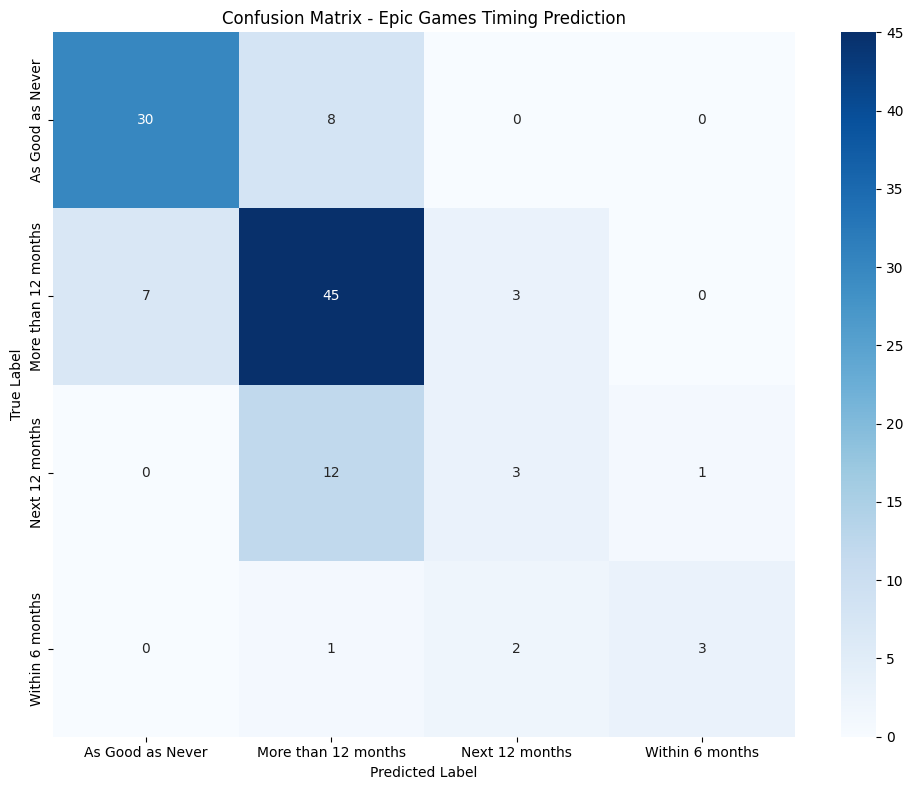

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions on test set
y_pred = xgb_model.predict(X_test)

# Classification report
print("\nClassification Report:")
print("="*80)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Epic Games Timing Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [22]:
# ==========================================================
# Step 11.5: Interactive Publisher Test
# ==========================================================

# Interactive test to predict based on publisher input
def test_publisher_input():
    print("\n=== Epic Games Prediction Test ===")
    
    game_name = input("Enter a game name: ").strip()
    publisher = input("Enter publisher name: ").strip()
    
    try:
        metacritic = float(input("Enter Metacritic score (or press Enter if unknown): ") or "nan")
    except ValueError:
        metacritic = None
    
    release_year = input("Enter release year (default 2024): ").strip()
    release_year = int(release_year) if release_year else 2024
    
    release_month = input("Enter release month (1–12, default 6): ").strip()
    release_month = int(release_month) if release_month else 6

    # Run prediction
    result = predict_game_timing(
        game_name=game_name,
        publisher=publisher,
        metacritic_score=None if np.isnan(metacritic) else metacritic,
        release_year=release_year,
        release_month=release_month
    )

    # Print formatted result
    print("\n" + "="*70)
    print(f"Game Name     : {result['game_name']}")
    print(f"Publisher     : {result['publisher']}")
    print(f"Prediction    : {result['prediction']}")
    print(f"Confidence    : {result['confidence']:.1f}%")
    print("-"*70)
    print(result['sentence'])
    print("="*70 + "\n")

# Run test
test_publisher_input()



=== Epic Games Prediction Test ===

Game Name     : 
Publisher     : Rockstar Games
Prediction    : Next 12 months
Confidence    : 58.9%
----------------------------------------------------------------------
Based on the publisher 'Rockstar Games', which has released 1 game on Epic Games Store with an average wait time of 6 years and 8 months (averaging a Metacritic score of 92.0), and considering '' without an available Metacritic score, the game is estimated to appear free on Epic Games Store: **Next 12 months** (confidence: 58.9%).

